In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
path = '/Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project'

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
df_pushed_year = pd.read_csv(f'{path}/Modeling/common_NPI_pushed_year_df_with_pca_1_scaled_type_tot_risk_covid_3.csv').drop('Unnamed: 0',axis=1)
df_origin = pd.read_csv(f'{path}/Modeling/original_year_with_type_risk_tot_risk_pca_covid_3.csv').drop('Unnamed: 0', axis=1)

In [5]:
df_train = df_pushed_year[df_pushed_year['year']<=2020].copy()
df_val = df_origin[df_origin['year']==2020].copy() # use 2020 data predict for 2021, the df_val_df dataset is in original year
df_val['year']=2021
df_val['Is_Covid']=1
actual_total_y = sum(df_origin[df_origin['year']==2021]['Tot_Mdcr_Pymt_Amt'])
actual_y = df_origin[df_origin['year']==2021]['Tot_Mdcr_Pymt_Amt']
actual_total_y

109259516579.438

In [6]:
df_2021 = df_origin[df_origin['year']==2021].copy()
actual_total_2022 = sum(df_origin[df_origin['year']==2022]['Tot_Mdcr_Pymt_Amt'])
df_2021['year'] = 2022
df_2021['Is_Covid'] = 0
df_2022 = df_origin[df_origin['year']==2022].copy()
df_2022['year'] = 2023
actual_total_2023 = sum(df_origin[df_origin['year']==2023]['Tot_Mdcr_Pymt_Amt'])

In [7]:
df_train.columns

Index(['Rndrng_NPI', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_State_Abrvtn',
       'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'Tot_HCPCS_Cds',
       'Tot_Benes', 'Tot_Srvcs', 'Bene_Avg_Age', 'Bene_Avg_Risk_Scre',
       'pca_1_scaled', 'Tot_Risk', 'APP_Tot_Risk', 'PrimaryCare_Tot_Risk',
       'MedicalSpecialtyOther_Tot_Risk', 'LabPathology_Tot_Risk',
       'PharmacyNutrition_Tot_Risk', 'state', 'Tot_Mdcr_Pymt_Amt', 'year',
       'Is_Covid'],
      dtype='object')

# Model 1 with offset = pca_1_scaled

In [8]:
formula = """Tot_Mdcr_Pymt_Amt
            ~ C(Is_Covid)
            + C(APP_Tot_Risk) + C(PrimaryCare_Tot_Risk) + C(MedicalSpecialtyOther_Tot_Risk) + C(LabPathology_Tot_Risk) + C(PharmacyNutrition_Tot_Risk)
            + cr(year,df=3)
        """

MODEL_1 = smf.glm(
    formula=formula,
    data=df_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    offset=np.log(df_train["pca_1_scaled"]),
).fit()

In [19]:
y_pred = MODEL_1.predict(df_val,offset=np.log(df_val['pca_1_scaled']))

In [20]:
sum(y_pred)/actual_total_y

0.8902228837252444

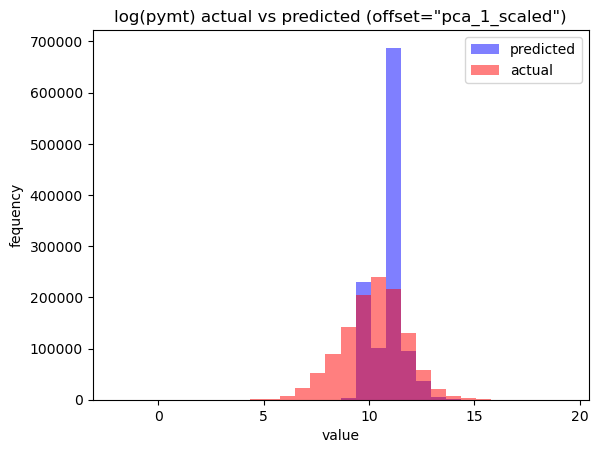

In [21]:
log_y_pred = np.log(y_pred.apply(lambda x:x if x!=0 else 1))
log_actual_y = np.log(actual_y.apply(lambda x:x if x!=0 else 1))

bins = np.histogram_bin_edges(np.concatenate([log_y_pred, log_actual_y]), bins=30)

plt.hist(log_y_pred, bins=bins, alpha=0.5, color="blue", label="predicted")
plt.hist(log_actual_y, bins=bins, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted (offset="pca_1_scaled")')
plt.show()

In [12]:
MODEL_1.summary()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:812: RuntimeWarning: divide by zero encountered in log
  ll_obs -= special.gammaln(weight_scale) + np.log(endog)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1891: RuntimeWarning: invalid value encountered in scalar subtract
  prsq = 1 - np.exp((self.llnull - self.llf) * (2 / self.nobs))


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880929
Model Family:                   Gamma   Df Model:                           14
Link Function:                    Log   Scale:                          5.8927
Method:                          IRLS   Log-Likelihood:                    inf
Date:                Mon, 09 Mar 2026   Deviance:                   1.2497e+07
Time:                        13:45:59   Pearson chi2:                 4.05e+07
No. Iterations:                   100   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                 2.541e+07   5.86e+07      0.433      0.665   -8.95e+07     1.4e+08
C(Is_Covid)[T.1]                            -0.1094      0.005    -23.097      0.000      -0.119      -0.100
C(APP_Tot_Risk)[T.1.0]                      -1.6231      0.018    -90.664      0.000      -1.658      -1.588
C(APP_Tot_Risk)[T.2.0]                      -0.2312      0.018    -12.996      0.000      -0.266      -0.196
C(PrimaryCare_Tot_Risk)[T.1.0]               0.7753      0.004    178.524      0.000       0.767       0.784
C(PrimaryCare_Tot_Risk)[T.2.0]               0.7166      0.003    216.888      0.000       0.710       0.723
C(MedicalSpecialtyOther_Tot_Risk)[T.1.0]    -0.9478      0.007   -143.690      0.000      -0.961      -0.935
C(MedicalSpecialtyOther_Tot_Risk)[T.2.0]    -0.8540      0.005   -172.278      0.000      -0.864      -0.844
C(LabPathology_Tot_Risk)[T.1.0]              1.0593      0.030     35.259      0.000       1.000       1.118
C(LabPathology_Tot_Risk)[T.2.0]             -1.9236      0.018   -109.136      0.000      -1.958      -1.889
C(LabPathology_Tot_Risk)[T.3.0]             -1.5274      0.015   -104.812      0.000      -1.556      -1.499
C(PharmacyNutrition_Tot_Risk)[T.1.0]         3.2678      0.062     52.747      0.000       3.146       3.389
C(PharmacyNutrition_Tot_Risk)[T.2.0]         2.4095      0.023    102.790      0.000       2.364       2.455
cr(year, df=3)[0]                        -2.541e+07   5.86e+07     -0.433      0.665    -1.4e+08    8.95e+07
cr(year, df=3)[1]                        -2.541e+07   5.86e+07     -0.433      0.665    -1.4e+08    8.95e+07
cr(year, df=3)[2]                        -2.541e+07   5.86e+07     -0.433      0.665    -1.4e+08    8.95e+07
============================================================================================================
"""

MODEL_1 has a terrible histogram, but the total amount prediction is ok. Scatter plot is miserable as well.

# Model 2 with offset = Tot_Srvcs

In [13]:
formula = """Tot_Mdcr_Pymt_Amt
            ~ C(Is_Covid)
            + C(APP_Tot_Risk) + C(PrimaryCare_Tot_Risk) + C(MedicalSpecialtyOther_Tot_Risk) + C(LabPathology_Tot_Risk) + C(PharmacyNutrition_Tot_Risk)
            + cr(year,df=3)
        """

MODEL_2 = smf.glm(
    formula=formula,
    data=df_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    offset=np.log(df_train["Tot_Srvcs"]),
).fit()

In [14]:
y_pred = MODEL_2.predict(df_val,offset=np.log(df_val['Tot_Srvcs']))

In [15]:
sum(y_pred)/actual_total_y

2.250982245239444

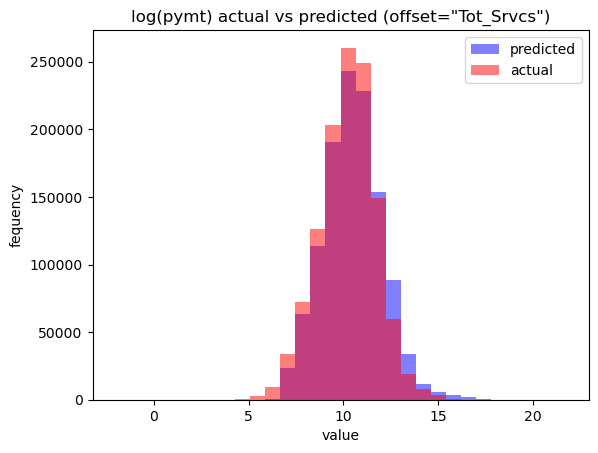

In [17]:
log_y_pred = np.log(y_pred.apply(lambda x:x if x!=0 else 1))
log_actual_y = np.log(actual_y.apply(lambda x:x if x!=0 else 1))

bins = np.histogram_bin_edges(np.concatenate([log_y_pred, log_actual_y]), bins=30)

plt.hist(log_y_pred, bins=bins, alpha=0.5, color="blue", label="predicted")
plt.hist(log_actual_y, bins=bins, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted (offset="Tot_Srvcs")')
plt.show()

In [ ]:
MODEL_2.summary()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:812: RuntimeWarning: divide by zero encountered in log
  ll_obs -= special.gammaln(weight_scale) + np.log(endog)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1891: RuntimeWarning: invalid value encountered in scalar subtract
  prsq = 1 - np.exp((self.llnull - self.llf) * (2 / self.nobs))


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880909
Model Family:                   Gamma   Df Model:                           34
Link Function:                    Log   Scale:                          16.421
Method:                          IRLS   Log-Likelihood:                    inf
Date:                Sun, 08 Mar 2026   Deviance:                   5.7678e+06
Time:                        19:57:13   Pearson chi2:                 1.13e+08
No. Iterations:                   100   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
===================================================================================================================
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                                        7.821e+05   3.35e+08      0.002      0.998   -6.57e+08    6.58e+08
C(Is_Covid)[T.1]                                   -0.1510      0.009    -17.005      0.000      -0.168      -0.134
C(Rndrng_Prvdr_Type)[T.AcuteCare]               -1.383e+06   3.84e+07     -0.036      0.971   -7.66e+07    7.39e+07
C(Rndrng_Prvdr_Type)[T.Anesthesia]              -1.383e+06   3.84e+07     -0.036      0.971   -7.66e+07    7.39e+07
C(Rndrng_Prvdr_Type)[T.BehavioralHealth]        -1.383e+06   3.84e+07     -0.036      0.971   -7.66e+07    7.39e+07
C(Rndrng_Prvdr_Type)[T.CardioVascularSurgery]   -1.383e+06   3.84e+07     -0.036      0.971   -7.66e+07    7.39e+07
C(Rndrng_Prvdr_Type)[T.Cardiology]              -1.383e+06   3.84e+07     -0.036      0.971   -7.66e+07    7.39e+07
C(Rndrng_Prvdr_Type)[T.FacilitySupplierProgram] -1.383e+06   3.84e+07     -0.036      0.971   -7.66e+07    7.39e+07
C(Rndrng_Prvdr_Type)[T.LabPathology]            -4.319e+06    4.8e+08     -0.009      0.993   -9.45e+08    9.37e+08
C(Rndrng_Prvdr_Type)[T.MedicalSpecialtyOther]   -1.513e+07   2.69e+08     -0.056      0.955   -5.42e+08    5.12e+08
C(Rndrng_Prvdr_Type)[T.OBGYN]                   -1.383e+06   3.84e+07     -0.036      0.971   -7.66e+07    7.39e+07
C(Rndrng_Prvdr_Type)[T.OncologyHeme]            -1.383e+06   3.84e+07     -0.036      0.971   -7.66e+07    7.39e+07
C(Rndrng_Prvdr_Type)[T.PharmacyNutrition]       -3.524e+07   1.19e+09     -0.030      0.976   -2.37e+09     2.3e+09
C(Rndrng_Prvdr_Type)[T.PrimaryCare]             -9.224e+06   4.39e+08     -0.021      0.983    -8.7e+08    8.52e+08
C(Rndrng_Prvdr_Type)[T.RadiologyImaging]        -1.383e+06   3.84e+07     -0.036      0.971   -7.66e+07    7.39e+07
C(Rndrng_Prvdr_Type)[T.RehabTherapy]            -1.383e+06   3.84e+07     -0.036      0.971   -7.66e+07    7.39e+07
C(Rndrng_Prvdr_Type)[T.SurgeryOther]            -1.383e+06   3.84e+07     -0.036      0.971   -7.66e+07    7.39e+07
C(Rndrng_Prvdr_Type)[T.UnknownOther]            -1.383e+06   3.84e+07     -0.036      0.971   -7.66e+07    7.39e+07
C(Rndrng_Prvdr_Type)[T.VisionHearing]           -1.383e+06   3.84e+07     -0.036      0.971   -7.66e+07    7.39e+07
C(APP_Tot_Risk)[T.1.0]                              0.1457      0.030      4.873      0.000       0.087       0.204
C(APP_Tot_Risk)[T.2.0]                           1.383e+06   3.84e+07      0.036      0.971   -7.39e+07    7.66e+07
C(PrimaryCare_Tot_Risk)[T.1.0]                     -0.4063      0.007    -54.762      0.000      -0.421      -0.392
C(PrimaryCare_Tot_Risk)[T.2.0]                  -7.841e+06   4.49e+08     -0.017      0.986   -8.87e+08    8.72e+08
C(MedicalSpecialtyOther_Tot_Risk)[T.1.0]            0.0552      0.0

MODEL_2 has a much BETTER histogram, but the total amount prediction is terrible. Scatter plot is questionable as well.

# Model 3 with offset = Tot_Benes

In [22]:
formula = """Tot_Mdcr_Pymt_Amt
            ~ C(Is_Covid)
            + C(APP_Tot_Risk) + C(PrimaryCare_Tot_Risk) + C(MedicalSpecialtyOther_Tot_Risk) + C(LabPathology_Tot_Risk) + C(PharmacyNutrition_Tot_Risk)
            + cr(year,df=3)
        """

MODEL_3 = smf.glm(
    formula=formula,
    data=df_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    offset=np.log(df_train["Tot_Benes"].apply(lambda x:x if x!=0 else 1)),
).fit()

In [23]:
y_pred = MODEL_3.predict(df_val,offset=np.log(df_val['Tot_Benes'].apply(lambda x:x if x!=0 else 1)))

In [24]:
sum(y_pred)/actual_total_y

1.1023471382314278

In [25]:
sum(MODEL_3.predict(df_2021,offset=np.log(df_2021['Tot_Benes'].apply(lambda x:x if x!=0 else 1))))/actual_total_2022

1.5178309584988063

In [26]:
sum(MODEL_3.predict(df_2022,offset=np.log(df_2022['Tot_Benes'].apply(lambda x:x if x!=0 else 1))))/actual_total_2023

1.3827536034137213

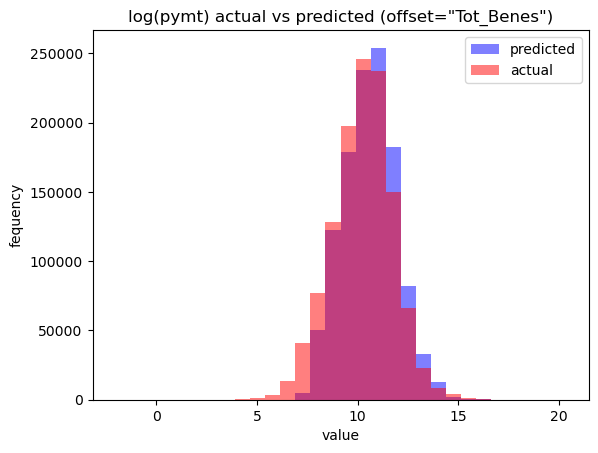

In [27]:
log_y_pred = np.log(y_pred.apply(lambda x:x if x!=0 else 1))
log_actual_y = np.log(actual_y.apply(lambda x:x if x!=0 else 1))

bins = np.histogram_bin_edges(np.concatenate([log_y_pred, log_actual_y]), bins=30)

plt.hist(log_y_pred, bins=bins, alpha=0.5, color="blue", label="predicted")
plt.hist(log_actual_y, bins=bins, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted (offset="Tot_Benes")')
plt.show()

In [40]:
MODEL_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880909
Model Family:                   Gamma   Df Model:                           34
Link Function:                    Log   Scale:                          12.806
Method:                          IRLS   Log-Likelihood:                    inf
Date:                Sun, 08 Mar 2026   Deviance:                   5.8514e+06
Time:                        20:21:09   Pearson chi2:                 8.81e+07
No. Iterations:                   100   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
===================================================================================================================
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                                         2.24e+07   3.07e+08      0.073      0.942   -5.79e+08    6.24e+08
C(Is_Covid)[T.1]                                   -0.1327      0.008    -17.209      0.000      -0.148      -0.118
C(Rndrng_Prvdr_Type)[T.AcuteCare]               -4.922e+06   3.41e+07     -0.144      0.885   -7.18e+07    6.19e+07
C(Rndrng_Prvdr_Type)[T.Anesthesia]              -4.922e+06   3.41e+07     -0.144      0.885   -7.18e+07    6.19e+07
C(Rndrng_Prvdr_Type)[T.BehavioralHealth]        -4.922e+06   3.41e+07     -0.144      0.885   -7.18e+07    6.19e+07
C(Rndrng_Prvdr_Type)[T.CardioVascularSurgery]   -4.922e+06   3.41e+07     -0.144      0.885   -7.18e+07    6.19e+07
C(Rndrng_Prvdr_Type)[T.Cardiology]              -4.922e+06   3.41e+07     -0.144      0.885   -7.18e+07    6.19e+07
C(Rndrng_Prvdr_Type)[T.FacilitySupplierProgram] -4.922e+06   3.41e+07     -0.144      0.885   -7.18e+07    6.19e+07
C(Rndrng_Prvdr_Type)[T.LabPathology]            -3.226e+07   4.24e+08     -0.076      0.939   -8.63e+08    7.99e+08
C(Rndrng_Prvdr_Type)[T.MedicalSpecialtyOther]   -1.196e+07   2.39e+08     -0.050      0.960    -4.8e+08    4.56e+08
C(Rndrng_Prvdr_Type)[T.OBGYN]                   -4.922e+06   3.41e+07     -0.144      0.885   -7.18e+07    6.19e+07
C(Rndrng_Prvdr_Type)[T.OncologyHeme]            -4.922e+06   3.41e+07     -0.144      0.885   -7.18e+07    6.19e+07
C(Rndrng_Prvdr_Type)[T.PharmacyNutrition]        3.382e+07   9.36e+08      0.036      0.971    -1.8e+09    1.87e+09
C(Rndrng_Prvdr_Type)[T.PrimaryCare]              7.682e+06   3.89e+08      0.020      0.984   -7.54e+08     7.7e+08
C(Rndrng_Prvdr_Type)[T.RadiologyImaging]        -4.922e+06   3.41e+07     -0.144      0.885   -7.18e+07    6.19e+07
C(Rndrng_Prvdr_Type)[T.RehabTherapy]            -4.922e+06   3.41e+07     -0.144      0.885   -7.18e+07    6.19e+07
C(Rndrng_Prvdr_Type)[T.SurgeryOther]            -4.922e+06   3.41e+07     -0.144      0.885   -7.18e+07    6.19e+07
C(Rndrng_Prvdr_Type)[T.UnknownOther]            -4.922e+06   3.41e+07     -0.144      0.885   -7.18e+07    6.19e+07
C(Rndrng_Prvdr_Type)[T.VisionHearing]           -4.922e+06   3.41e+07     -0.144      0.885   -7.18e+07    6.19e+07
C(APP_Tot_Risk)[T.1.0]                             -1.9800      0.026    -74.968      0.000      -2.032      -1.928
C(APP_Tot_Risk)[T.2.0]                           4.922e+06   3.41e+07      0.144      0.885   -6.19e+07    7.18e+07
C(PrimaryCare_Tot_Risk)[T.1.0]                      0.7501      0.007    114.493      0.000       0.737       0.763
C(PrimaryCare_Tot_Risk)[T.2.0]                    1.26e+07   3.97e+08      0.032      0.975   -7.65e+08     7.9e+08
C(MedicalSpecialtyOther_Tot_Risk)[T.1.0]           -1.1078      0.0

MODEL_3 has the best histogram and best ratio of tot pymts! I will keep using Tot_Benes as offset.
The following is MODEL_3's coef ranking according to their p-value.

In [28]:
ranked_coef = pd.DataFrame({
        "coef": MODEL_3.params,
        "p_value": MODEL_3.pvalues
    }).sort_values("p_value")

print(ranked_coef[ranked_coef['p_value']<=0.05])

                                              coef        p_value
C(APP_Tot_Risk)[T.1.0]                   -1.924439   0.000000e+00
C(PrimaryCare_Tot_Risk)[T.1.0]            0.538867   0.000000e+00
C(PrimaryCare_Tot_Risk)[T.2.0]            0.647211   0.000000e+00
C(MedicalSpecialtyOther_Tot_Risk)[T.1.0] -0.784678   0.000000e+00
C(PharmacyNutrition_Tot_Risk)[T.1.0]      4.304593  3.473864e-249
C(MedicalSpecialtyOther_Tot_Risk)[T.2.0] -0.337158  7.036931e-239
C(LabPathology_Tot_Risk)[T.1.0]           2.004204  7.367517e-230
C(APP_Tot_Risk)[T.2.0]                   -1.140752  1.320127e-212
C(LabPathology_Tot_Risk)[T.2.0]          -0.798261  4.932668e-107
C(PharmacyNutrition_Tot_Risk)[T.2.0]      1.058558  1.969440e-106
C(LabPathology_Tot_Risk)[T.3.0]           0.509877   1.192175e-64
C(Is_Covid)[T.1]                         -0.117503   2.396497e-33


# Model 4 without offset

In [29]:
formula = """Tot_Mdcr_Pymt_Amt
            ~ C(Is_Covid)
            + C(APP_Tot_Risk) + C(PrimaryCare_Tot_Risk) + C(MedicalSpecialtyOther_Tot_Risk) + C(LabPathology_Tot_Risk) + C(PharmacyNutrition_Tot_Risk)
            + cr(year,df=3)
        """

MODEL_4 = smf.glm(
    formula=formula,
    data=df_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    #offset=np.log(df_train["Tot_Benes"].apply(lambda x:x if x!=0 else 1)),
).fit()

In [30]:
y_pred = MODEL_4.predict(df_val)

In [31]:
sum(y_pred)/actual_total_y

0.9369936386989358

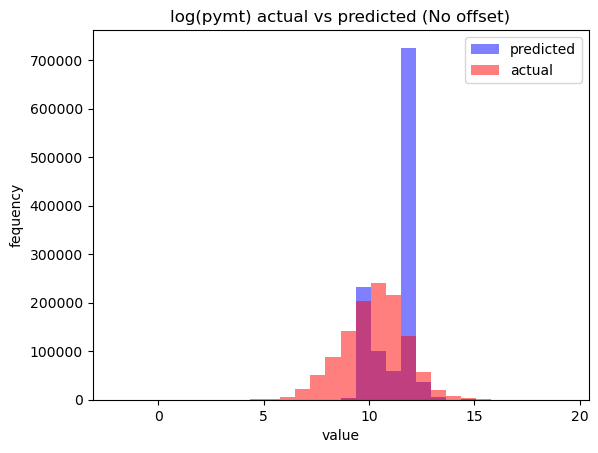

In [32]:
log_y_pred = np.log(y_pred.apply(lambda x:x if x!=0 else 1))
log_actual_y = np.log(actual_y.apply(lambda x:x if x!=0 else 1))

bins = np.histogram_bin_edges(np.concatenate([log_y_pred, log_actual_y]), bins=30)

plt.hist(log_y_pred, bins=bins, alpha=0.5, color="blue", label="predicted")
plt.hist(log_actual_y, bins=bins, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted (No offset)')
plt.show()

Without offset, despite the total ratio being OK, the actual prediction is clearly off in comparsion to MODEL_3.